In [ ]:
'''
As the particles diffuse, their shape changes over time. 
As we have the particle vicinity from the previous frame, we can use particle detection
If this fails too, still remember the particle location for future frames

Once the particle is detected in 1 frame, 
    the video detection of these particles doesn't need strict filters.
    This is becuase the particle shape changes with time
    Only use the aspect ratio filter

Save excel after:
    1. Every particle finding cycle
    2. Entire video

This function is only finding the particles in the forward direction. 
    Do we want something for the backward direction too?
'''

In [1]:
import os
import cv2
#import numpy as np
import pandas as pd

import time

from hydrogel_utils import *
from utils import *
from bbox_tuning import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
video_name = 'IMG_1234_frames450_crop480_1080 0_600_fps15.mp4'
video_path = os.path.join('Videos_cropped', video_name)

save_folder = 'output_files'
if save_folder not in os.listdir():
    os.mkdir(save_folder)

excel_save_name = f'{os.path.splitext(video_name)[0]}.xlsx'
excel_save_path = os.path.join(save_folder, excel_save_name)

#Trying out the function
frame_index = 0

#Particle and frame info
particle_to_use = [0, 1, 2] #[0, 1, 2, 3, 4]
particle_shape = "Gaussian" #Gaussian/Defocused
box = "Overfit" #Underfit/Overfit/Corner

#Search configuration
search_config = {
    'max_iterations': 5, #25 #50 #100
    'iteration_memory': 3,
    'max_iteration_time_seconds': 60,
    'parallel_processing': True
}

#Annotate in video
video_annotate_config = {'frames_to_use': 25, #100 #0 #20 #50 #
                        'search_range': 10,
                        'initial_search_by': 'matching', #matching/previous_location
                        }

#Matching variables
matching_config = {'Threshold': 0.9, 'adaptive_scale': 0.95}

#Cleaning variables
postprocess_config = {'NMSoverlapThresh': 0.7, 'NMSareaDiff': 0.5, 'ar_range': [2/3, 3/2], 'PSNR': 23.5} #'min_traj_len': frames_to_use//4


#Edge detection variables
edge_detection_config = {'pixel_pad': 5, 'edge_relThresh': 0.25}

#Video annotation saving parameters
video_output_config = {'save_folder': save_folder, 'excel_save_name': f'{video_name.split(".")[0]}.xlsx', 
                  'video_save_name': f'{video_name.split(".")[0]}_annotated.mp4', 'video_fps': 3,
                    'show_object_id': False, 'show_frame_number': True
                    }

#Read video
vidcap = cv2.VideoCapture(video_path)

Initial dimensions: x_tl = 187, y_tl = 86, w = 16, h = 17
Processing human made particle 0, h = 17, w = 16
Using new object for assisted annotations
Objects found after iteration 1 = 18 with Δt = 18.29s
Objects found after iteration 2 = 20 with Δt = 0.96s
Objects found after iteration 3 = 26 with Δt = 1.03s
Objects found after iteration 4 = 29 with Δt = 1.17s
Objects found after iteration 5 = 49 with Δt = 1.62s
Ready for the next annotation

Initial dimensions: x_tl = 136, y_tl = 486, w = 12, h = 12
Processing human made particle 1, h = 12, w = 12
Using new object for assisted annotations
Objects found after iteration 1 = 57 with Δt = 1.61s
Objects found after iteration 2 = 66 with Δt = 1.59s
Objects found after iteration 3 = 75 with Δt = 1.75s
Objects found after iteration 4 = 80 with Δt = 1.86s
Objects found after iteration 5 = 93 with Δt = 8.35s
Ready for the next annotation

Initial dimensions: x_tl = 250, y_tl = 209, w = 8, h = 8
Processing human made particle 2, h = 8, w = 8
Usin

,x top left,y top left,width,height,Aspect ratio,frame,madeBy,edgeThreshold,humanMade,nms applied,new object,objectID,Detection Similarity,PSNR
0,298.1,7.4,13.6,16.6,0.82,0,Detected,0.25,False,True,True,0,0.410193,17.952219
1,42.5,8.2,11.3,13.4,0.84,0,Detected,0.25,False,True,True,1,0.714734,18.577513
2,43.4,9.4,8.4,10.2,0.82,0,Detected,0.25,False,True,True,2,0.836847,14.497296
3,351.1,25.5,9.9,12.7,0.78,0,Detected,0.25,False,True,True,3,0.374225,21.029724
4,311.3,35.3,8.5,8.4,1.01,0,Detected,0.25,False,True,True,4,0.780887,13.760084


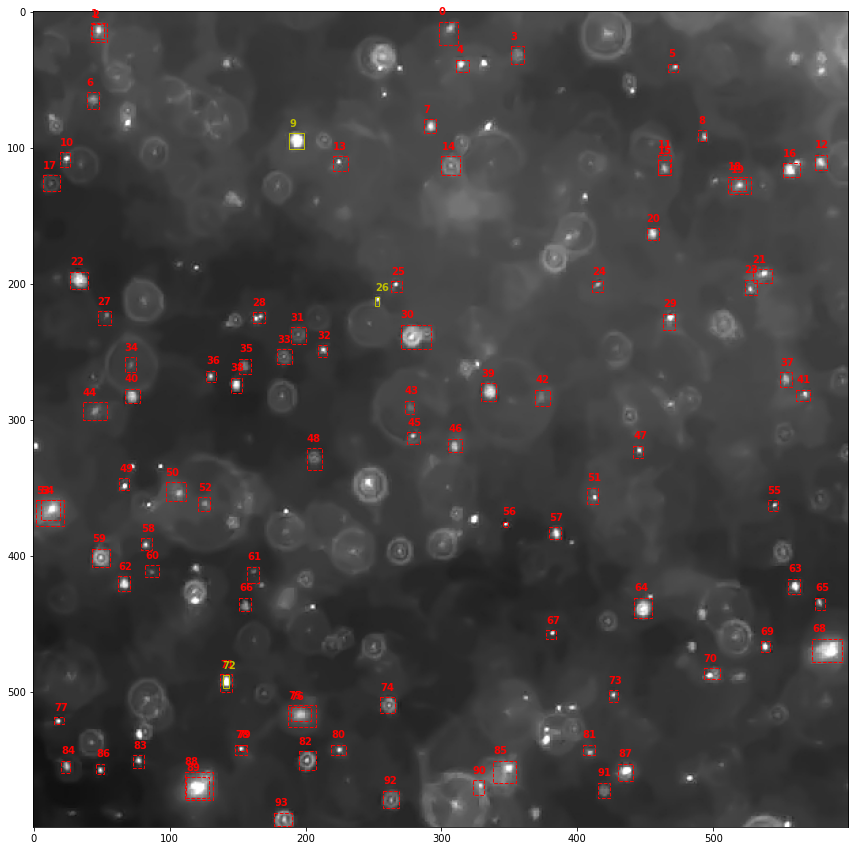

In [3]:
#Start an empty dataframe
df = pd.DataFrame()

#Get current frame
currentFrame = load_frame(vidcap, frame_index=frame_index)

for particle_number in particle_to_use:
    y_tl, x_tl, h, w, madeBy = toy_locations(particle_shape, box, particle_number)
    print(f"Processing human made particle {particle_number}, {h = }, {w = }")
    
    #Put the detected box in the dataframe
    d = {'x top left': [x_tl], 'y top left': [y_tl], 'width': [w], 'height': [h],
         'Aspect ratio': [round(w/h, 2)], 'frame': [0], 'madeBy': [madeBy], 'edgeThreshold': False, 
         'humanMade': True, 'nms applied': False, 'new object': True}
    
    #This df will start with one element and will change in size as we go through the code
    df_new_annotation = pd.DataFrame(data=d)

    #Refine this annotation
    df_merged = refine_human_annotation(df_new_annotation, df, currentFrame, edge_detection_config, search_config)
    
    #Iteratively find the new annotations and suppress them
    df = iterative_find_and_supress(df_merged, currentFrame, matching_config, edge_detection_config, 
                                    search_config, postprocess_config)

#print(f"Particles found before NMS = {len(df)}")
#NMS is already applied to the entire df in the find and suppress function
#df = non_max_suppression(df, clean_dict['NMSoverlapThresh'])
#df = nms_with_area(df, clean_dict['NMSoverlapThresh'], clean_dict['NMSareaDiff'])
print(f"Total particles found = {len(df)}")
df = df.sort_values(by=['y top left', 'x top left']).reset_index(drop=True)
#Adding particle ID
df['objectID'] = df.index
df.to_excel(excel_save_path, index=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df[:5])

#Display annotations
display_annotations_on_frame(currentFrame, df, display_number=True)

Particles remaining = 99


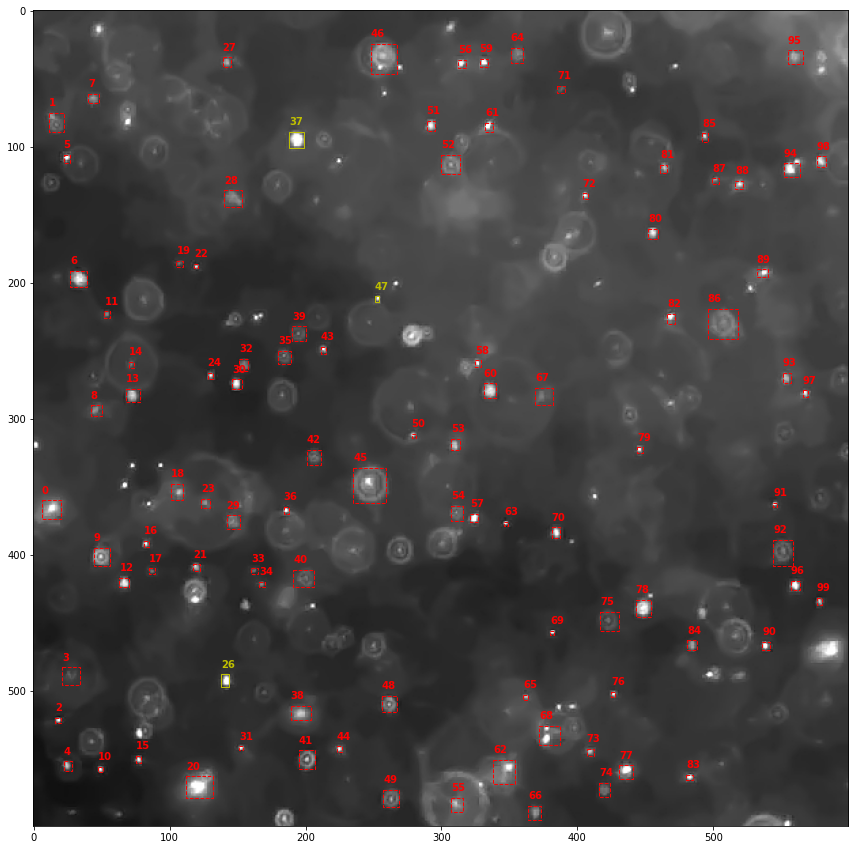

In [5]:
#Remove annotations
particle_to_remove = [25] #46

df = df[~df['objectID'].isin(particle_to_remove)]
print(f'Particles remaining = {len(df)}')

#Display annotations
display_annotations_on_frame(currentFrame, df, display_number=True)

In [4]:
#Detect template in the entire video
#Is adaptive ROI bad here?
df_video = annotate_objects_in_video(vidcap, df, video_annotate_dict, detection_dict, #match_threshold, 
                                    clean_dict, video_save_dict)

#df.to_excel('Temp Image.xlsx', index=False)
#df_video.to_excel('Temp Video.xlsx', index=False)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_video[:4])

Total objects: 44
Objects found in frame 1: 42, Running Total = 86
Objects found in frame 2: 43, Running Total = 129
Objects found in frame 3: 42, Running Total = 171
Objects found in frame 4: 42, Running Total = 213
Objects found in frame 5: 41, Running Total = 254
Objects found in frame 6: 41, Running Total = 295
Objects found in frame 7: 41, Running Total = 336
Objects found in frame 8: 43, Running Total = 379
Objects found in frame 9: 42, Running Total = 421
Objects found in frame 10: 41, Running Total = 462
Objects found in frame 11: 43, Running Total = 505
Objects found in frame 12: 43, Running Total = 548
Objects found in frame 13: 42, Running Total = 590
Objects found in frame 14: 44, Running Total = 634
Objects found in frame 15: 43, Running Total = 677
Objects found in frame 16: 43, Running Total = 720
Objects found in frame 17: 41, Running Total = 761
Objects found in frame 18: 41, Running Total = 802
Objects found in frame 19: 40, Running Total = 842
Objects found in frame 

,x top left,y top left,width,height,Aspect ratio,frame,madeBy,humanMade,nms applied,new object,edgeThreshold,objectID,Detection Similarity,PSNR,x center,y center,width std,height std
0,43.1,9.1,10.5,10.6,0.99,0,Detected,False,True,True,0.25,0,0.741878,17.715217,48.35,14.4,3.894226,3.445591
1,311.4,35.3,8.2,8.3,0.99,0,Detected,False,True,True,0.25,1,0.643921,12.099179,315.5,39.45,2.751796,1.845792
2,39.3,59.6,8.5,11.6,0.73,0,Detected,False,True,True,0.25,2,0.635793,20.658899,43.55,65.4,0.870479,0.676708
3,287.5,79.3,8.2,9.3,0.88,0,Detected,False,True,True,0.25,3,0.282720,11.818320,291.6,83.95,1.190196,0.981971


In [ ]:
#Save video
video_save_path = os.path.join('output_files', f'{video_name.split(".")[0]}_annotated.mp4')
annotated_video = make_annotated_video(df_video, vidcap, fps=3, save_path=video_save_path, show_frame_number=True)

#Temporary metrics
error_levels = 5
quantiles = [np.linspace(0, 1, error_levels)][0]
for item in quantiles:
    print("Quantile: {}, width std: {}, height std: {}".format(item, round(df_video['width std'].quantile(item), 2),
                                                      round(df_video['height std'].quantile(item), 2)))

In [ ]:
#Apply Filters and save excel
df_video_cleaned = video_filters(df, clean_dict, excel_save_path)

In [ ]:
#View some frames of the annotated video once filtering is done
#This will help us understand which objects have been removed

In [ ]:
#View some frames of the annotated video
instances_to_view = 5
frame_skip = frames_to_use//instances_to_view
#frame_skip = 1

vizualize_frames(df_video, vidcap, frame_skip)